#  Building a machine learning model that predicts weather a person has heart disease or not 

In [30]:
import pandas as pd
data = pd.read_csv("heart-disease.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [31]:
data = data.drop_duplicates()

In [32]:
import sklearn

# Check version
print(sklearn.__version__)

1.7.1


In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [34]:
data["target"].unique()

array([1, 0], dtype=int64)

In [35]:
X = data.drop("target", axis=1)
y = data["target"]

In [36]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
clf = RandomForestClassifier(random_state=42)

In [38]:
clf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
y_preds = clf.predict(np.array(x_test))
y_preds

C:\Users\USER\miniconda3\envs\jupyter_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [40]:
np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [41]:
clf.score(x_train, y_train)

1.0

In [42]:
clf.score(x_test, y_test)*100

86.88524590163934

# Accuracy

In [43]:
from sklearn.model_selection import cross_val_score

In [44]:
cross_val_score = cross_val_score(clf, X,y, cv=5, scoring= None)


In [45]:
np.mean(cross_val_score)*100

82.43169398907104

# AREA UNDER ROC CURVE

In [46]:
from sklearn.metrics import roc_curve
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

In [47]:
y_probs = clf.predict_proba(x_test)*100

In [48]:
y_probs

array([[ 96.,   4.],
       [ 71.,  29.],
       [ 52.,  48.],
       [ 67.,  33.],
       [ 19.,  81.],
       [ 13.,  87.],
       [ 36.,  64.],
       [ 96.,   4.],
       [ 96.,   4.],
       [ 41.,  59.],
       [ 20.,  80.],
       [ 89.,  11.],
       [  9.,  91.],
       [ 84.,  16.],
       [  5.,  95.],
       [  2.,  98.],
       [  0., 100.],
       [100.,   0.],
       [ 96.,   4.],
       [ 93.,   7.],
       [ 61.,  39.],
       [ 95.,   5.],
       [ 31.,  69.],
       [ 22.,  78.],
       [ 23.,  77.],
       [ 27.,  73.],
       [ 84.,  16.],
       [ 25.,  75.],
       [ 93.,   7.],
       [ 25.,  75.],
       [ 85.,  15.],
       [ 89.,  11.],
       [ 66.,  34.],
       [ 66.,  34.],
       [ 46.,  54.],
       [ 73.,  27.],
       [ 48.,  52.],
       [ 15.,  85.],
       [ 35.,  65.],
       [ 15.,  85.],
       [ 17.,  83.],
       [ 25.,  75.],
       [ 19.,  81.],
       [ 27.,  73.],
       [ 25.,  75.],
       [ 58.,  42.],
       [ 44.,  56.],
       [  2.,

In [72]:
np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [49]:
y_probs = clf.predict_proba(x_test) [:, 1]*100
y_probs

array([  4.,  29.,  48.,  33.,  81.,  87.,  64.,   4.,   4.,  59.,  80.,
        11.,  91.,  16.,  95.,  98., 100.,   0.,   4.,   7.,  39.,   5.,
        69.,  78.,  77.,  73.,  16.,  75.,   7.,  75.,  15.,  11.,  34.,
        34.,  54.,  27.,  52.,  85.,  65.,  85.,  83.,  75.,  81.,  73.,
        75.,  42.,  56.,  98.,   6.,   7.,  10.,   0.,  73.,  78.,  14.,
        20.,   3.,  96.,  11.,  45.,  35.])

In [50]:
roc_auc_score(y_test, y_probs)*100

94.01939655172414

In [51]:
print(f"Model Heart Prediction score: {roc_auc_score(y_test, y_probs) * 100:.2f}% correct")


Model Heart Prediction score: 94.02% correct


In [52]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

In [53]:
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    """
    Plots a ROC curve given the false positive rate (fpr)
    and true positive rate (tpr) of a model.
    """
    # Plot ROC curve
    plt.plot(fpr, tpr, color="green", label="ROC")

    # Plot baseline (random guessing)
    plt.plot([0, 1], [0, 1], color="darkblue", linestyle="--", label="Guessing")

    # Labels
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

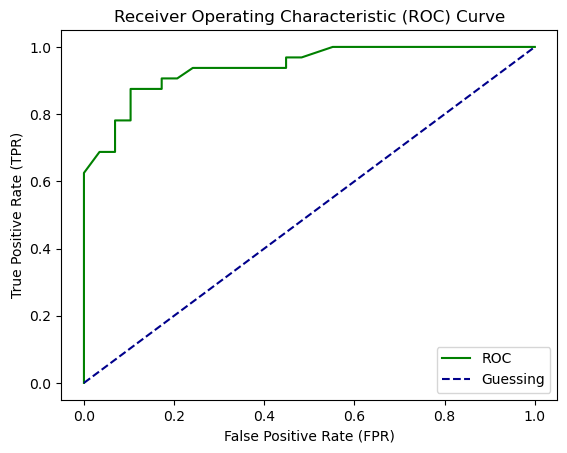

In [54]:
plot_roc_curve(fpr, tpr)

# confusion matrix

In [55]:
!pip install seaborn

In [56]:
import seaborn as sns

In [57]:
from sklearn.metrics import confusion_matrix

In [58]:
y_predict = clf.predict(x_test)
y_predict

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [59]:
confusion_matrix(y_test, y_predict)

array([[26,  3],
       [ 5, 27]], dtype=int64)

In [60]:
cm = confusion_matrix(y_test, y_predict)

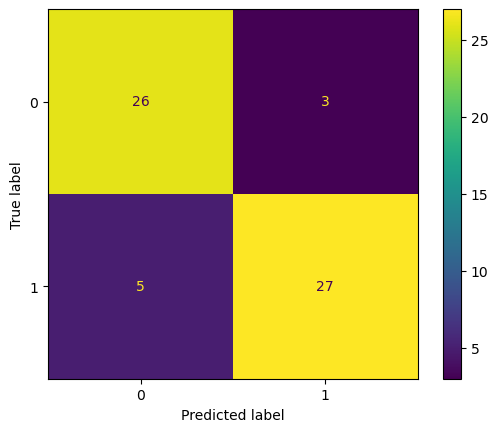

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_predict);

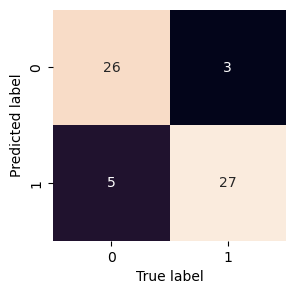

In [83]:
def plot_conf_mat(cm):
  """
  Plots a confusion matrix using Seaborn's heatmap().
  """
  fig, ax = plt.subplots(figsize=(3,3))
  ax = sns.heatmap(cm,
                    annot=True, # Annotate the boxes with cm info
                    cbar=False)
  plt.xlabel("True label")
  plt.ylabel("Predicted label")
plot_conf_mat(cm)

# Classification Report

In [79]:
from sklearn.metrics import classification_report
cr= classification_report(y_test, y_preds, output_dict= True)

In [82]:
cr_df = pd.DataFrame(cr).transpose()
cr_df.round(3)

,precision,recall,f1-score,support
0,0.839,0.897,0.867,29.000
1,0.900,0.844,0.871,32.000
accuracy,0.869,0.869,0.869,0.869
macro avg,0.869,0.870,0.869,61.000
weighted avg,0.871,0.869,0.869,61.000
